## 1: Load and Clean the Messy Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

# 1. Load the data
df = pd.read_csv('zomato.csv')

# 2. Keep only the columns we need for business strategy
df = df[['name', 'online_order', 'book_table', 'rate', 'votes', 'location', 'rest_type', 'cuisines', 'approx_cost(for two people)']]

# 3. Clean the 'rate' column (It looks like '4.1/5' or 'NEW' or '-')
def clean_rate(value):
    if pd.isnull(value) or value == 'NEW' or value == '-':
        return np.nan
    else:
        # Split by '/' and keep the first part, convert to float
        return float(str(value).split('/')[0].strip())

df['rating'] = df['rate'].apply(clean_rate)

# 4. Clean the 'approx_cost' column (Remove commas so we can do math on the ₹ amount)
def clean_cost(value):
    if pd.isnull(value):
        return np.nan
    else:
        return float(str(value).replace(',', ''))

df['cost_for_two'] = df['approx_cost(for two people)'].apply(clean_cost)

# Drop nulls in our critical columns
df.dropna(subset=['rating', 'cost_for_two', 'location'], inplace=True)

print(f"Cleaned dataset shape: {df.shape}")

Cleaned dataset shape: (41418, 11)


## 2: Business Insight 1 - Where is the highest demand?

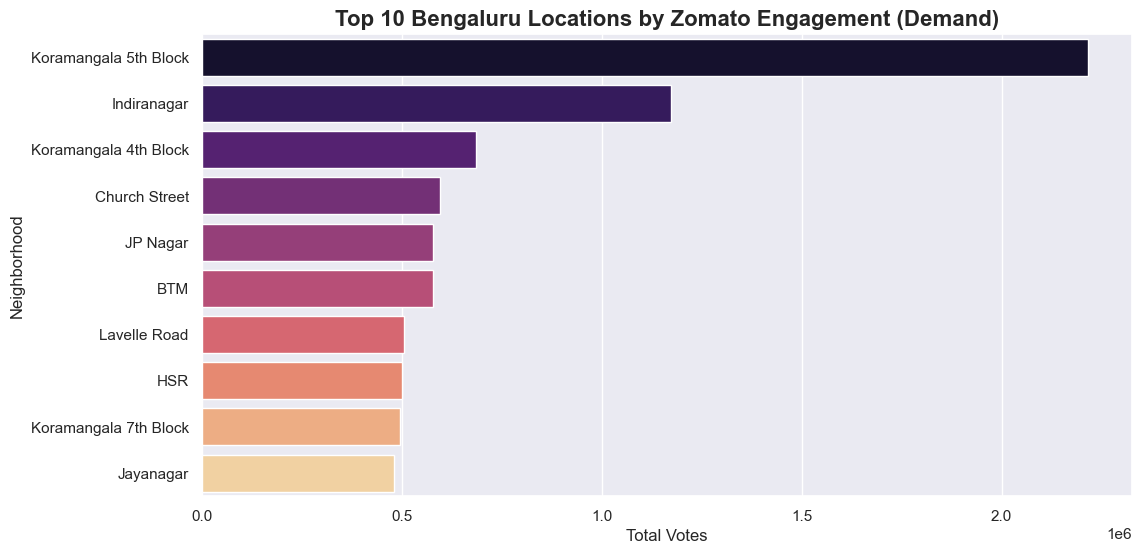

In [3]:
# Group by location
loc_stats = df.groupby('location').agg({
    'name': 'count',       # Number of restaurants (Competition)
    'votes': 'sum',        # Total votes (Demand/Engagement)
    'rating': 'mean'       # Average rating
}).reset_index()

# Filter for locations with decent demand to avoid outliers
loc_stats = loc_stats[loc_stats['name'] > 100]

# Sort by most votes
top_locations = loc_stats.sort_values(by='votes', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_locations, x='votes', y='location', palette='magma', hue='location', legend=False)
plt.title('Top 10 Bengaluru Locations by Zomato Engagement (Demand)', fontsize=16, fontweight='bold')
plt.xlabel('Total Votes', fontsize=12)
plt.ylabel('Neighborhood', fontsize=12)
plt.show()

##  3: Business Insight 2 - Pricing Strategy (Scatter Plot)

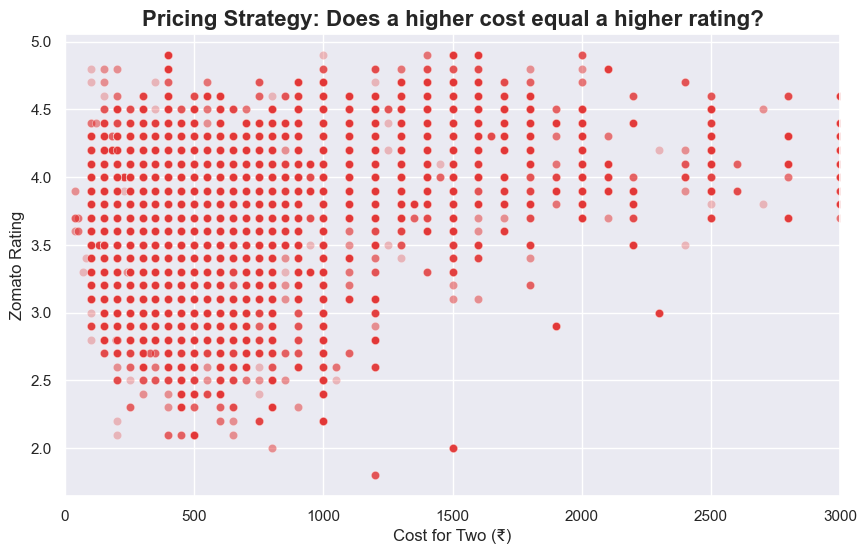

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='cost_for_two', y='rating', alpha=0.3, color='#e23737')
plt.title('Pricing Strategy: Does a higher cost equal a higher rating?', fontsize=16, fontweight='bold')
plt.xlabel('Cost for Two (₹)', fontsize=12)
plt.ylabel('Zomato Rating', fontsize=12)

# Zoom in on the majority of restaurants (Under ₹3000)
plt.xlim(0, 3000) 
plt.show()